# Global DQN Model — 300 Ausgrid Households

Trains a **single shared DQN agent** on 295 household datasets and evaluates it on 10 randomly chosen datasets:
- 5 **seen** (included in training)
- 5 **unseen** (held out from training entirely)

For every dataset the first 2/3 of timesteps are training data and the last 1/3 is the evaluation window.

## Cell 1 — Imports & device

In [26]:
import os
import sys
import copy
import json
import random
import importlib
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pulp

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from collections import deque
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

import Environment as environment_module
importlib.reload(environment_module)
HouseholdEnvironment = environment_module.HouseholdEnvironment

from Basic_Functions import calculate_interval_price
from Ploting_Functions import plotMultiY

# Device selection
if T.cuda.is_available():
    device = T.device('cuda')
    print(f'NVIDIA CUDA: {T.cuda.get_device_name(0)}')
elif T.backends.mps.is_available():
    device = T.device('mps')
    print('Apple Silicon MPS')
else:
    device = T.device('cpu')
    print('CPU')

Apple Silicon MPS


## Cell 2 — Configuration

In [ ]:
# ── Experiment ──────────────────────────────────────────────
SEED         = 42
N_HOLDOUT    = 5    # users withheld from training
N_EVAL_SEEN  = 5    # seen users selected for evaluation
DATA_DIR     = 'Datasorted by user'

# ── Physics (30-min step → scale rate limits accordingly) ───
BASE_STEP_MINUTES    = 15.0
DATASET_STEP_MINUTES = 30.0
step_scale           = DATASET_STEP_MINUTES / BASE_STEP_MINUTES  # = 2.0

KorakovNaDan     = int(round(1440 / DATASET_STEP_MINUTES))  # 48
BatKapaciteta    = 20.0
BatUcinkovitost  = 0.95
BatMaxPolnjenje  = 1.5 * step_scale   # 3.0 kWh/step
BatMaxPraznjenje = 1.5 * step_scale   # 3.0 kWh/step
faktorN1, faktorN2, faktorN3 = 0, 0, 1

# ── DQN hyper-parameters (best from single-user notebook) ───
fc1_dims, fc2_dims, fc3_dims = 256, 128, 64
lr             = 0.001
gamma          = 0.99
epsilon_start  = 1.0
epsilon_end    = 0.01
epsilon_decay  = 4e-5/4
batch_size     = 48
replace_target = KorakovNaDan * 7   # 336 steps
weight_decay   = 1e-4

# ── Training schedule ───────────────────────────────────────
N_ROUNDS           = 40 *2  # outer rounds
EPISODES_PER_ROUND = 10   # users sampled per round
EPISODE_STEPS      = KorakovNaDan * 7  # 1 week per episode

print(f'KorakovNaDan={KorakovNaDan}  BatMaxPol={BatMaxPolnjenje}  BatMaxPra={BatMaxPraznjenje}')

KorakovNaDan=48  BatMaxPol=3.0  BatMaxPra=3.0


## Cell 3 — Reproducible user split

In [28]:
rng = np.random.default_rng(SEED)

all_ids = list(range(1, 301))
rng.shuffle(all_ids)

holdout_ids = all_ids[:N_HOLDOUT]          # 5 unseen users
train_ids   = all_ids[N_HOLDOUT:]          # 295 training users

eval_seen   = rng.choice(train_ids, N_EVAL_SEEN, replace=False).tolist()
eval_unseen = holdout_ids                   # all 5 holdout users
eval_ids    = eval_seen + eval_unseen       # 10 total

print(f'Training users : {len(train_ids)}')
print(f'Holdout users  : {holdout_ids}')
print(f'Eval seen      : {eval_seen}')
print(f'Eval unseen    : {eval_unseen}')

Training users : 295
Holdout users  : [262, 294, 62, 254, 167]
Eval seen      : [242, 215, 43, 93, 19]
Eval unseen    : [262, 294, 62, 254, 167]


## Cell 4 — Load & split all 300 datasets

In [29]:
def load_ausgrid(uid):
    path = os.path.join(DATA_DIR, f'Ausgrid {uid}.csv')
    df = pd.read_csv(path)
    df.index = pd.to_datetime(df['Timestamp_UTC'], format='ISO8601')
    df = df.drop(columns=['Timestamp_UTC'])
    return df

print('Loading 300 datasets...')
train_dfs = {}
test_dfs  = {}

for uid in range(1, 301):
    df = load_ausgrid(uid)
    split = int(len(df) * 2 / 3)
    train_dfs[uid] = df.iloc[:split].copy()
    test_dfs[uid]  = df.iloc[split:].copy()

sample = train_dfs[1]
print(f'Loaded. Train rows: {len(sample)}  Test rows: {len(test_dfs[1])}')
print(f'Columns: {sample.columns.tolist()}')
print(f'Date range (train user 1): {sample.index[0]} → {sample.index[-1]}')

Loading 300 datasets...
Loaded. Train rows: 35072  Test rows: 17536
Columns: ['Energy_Consumption', 'Energy_Generation', 'SMP']
Date range (train user 1): 2010-07-01 00:30:00+00:00 → 2012-06-30 16:00:00+00:00


## Cell 5 — Global normalization (no data leakage)

In [30]:
# ── 5a. SMP price normalization ─────────────────────────────
# SMP is identical across all datasets; fit once on the training portion.

def normalize_electricity_prices(data, fit=False, params=None):
    """Log + clip + RobustScaler for SMP. Identical to single-user notebook."""
    if data.ndim == 1:
        data = data.reshape(-1, 1)

    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)
    log_data     = np.log1p(np.maximum(data, 0))
    log_lower    = np.log1p(max(0, lower_threshold))
    log_upper    = np.log1p(max(0, upper_threshold))
    clipped      = np.clip(log_data, log_lower, log_upper)

    if fit:
        scaler = RobustScaler()
        normalized = scaler.fit_transform(clipped)
        fitted_params = {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        normalized    = params['scaler'].transform(clipped)
        fitted_params = params

    return normalized, outlier_flag, fitted_params

# Fit SMP scaler on training portion of user 1 (SMP identical for all)
smp_train_ref = train_dfs[train_ids[0]]['SMP'].values
_, _, price_norm_params = normalize_electricity_prices(smp_train_ref, fit=True)
print('SMP price scaler fitted.')

# ── 5b. Energy (Gen + Con) global scaler ────────────────────
# Concatenate ALL training portions to learn a global distribution.
shared_cols = ['Energy_Generation', 'Energy_Consumption']

print('Building global energy scaler (concatenating 295 training sets)...')
combined_energy = np.concatenate([
    train_dfs[uid][shared_cols].values.flatten()
    for uid in train_ids
]).reshape(-1, 1)

global_energy_scaler = RobustScaler()
global_energy_scaler.fit(combined_energy)
print('Energy scaler fitted.')

# ── 5c. Apply to every dataset (train + test) ───────────────
def apply_normalization(df, split_label, uid):
    """Return a fully normalised copy of df."""
    df_n = df.copy()

    # Energy columns
    for col in shared_cols:
        df_n[col] = global_energy_scaler.transform(
            df[col].values.reshape(-1, 1)
        ).flatten()

    # SMP
    smp_norm, smp_flag, _ = normalize_electricity_prices(
        df['SMP'].values, fit=False, params=price_norm_params
    )
    df_n['SMP'] = smp_norm.flatten()
    df_n['SMP_OutlierFlag'] = smp_flag.flatten()

    return df_n

print('Normalising all 300 datasets (train + test)...')
train_norm_dfs = {uid: apply_normalization(train_dfs[uid], 'train', uid) for uid in range(1, 301)}
test_norm_dfs  = {uid: apply_normalization(test_dfs[uid],  'test',  uid) for uid in range(1, 301)}

print('Done.')
print('Sample normalised train stats (user 1):')
print(train_norm_dfs[1][['Energy_Consumption', 'Energy_Generation', 'SMP']].describe().round(3))

SMP price scaler fitted.
Building global energy scaler (concatenating 295 training sets)...
Energy scaler fitted.
Normalising all 300 datasets (train + test)...
Done.
Sample normalised train stats (user 1):
       Energy_Consumption  Energy_Generation        SMP
count           35072.000          35072.000  35072.000
mean                0.673              0.515      0.368
std                 1.020              1.462      1.578
min                -0.397             -0.397     -3.552
25%                -0.017             -0.397     -0.257
50%                 0.267             -0.397      0.000
75%                 1.027              1.000      0.743
max                 8.537              5.730     12.568


## Cell 6 — Environment factory

In [31]:
def make_env(uid, split='train', episode_length=None):
    """Create a HouseholdEnvironment for the given user and data split."""
    if split == 'train':
        data   = train_dfs[uid]
        data_n = train_norm_dfs[uid]
        reset_mode = 'random'
        ep_len = episode_length if episode_length is not None else EPISODE_STEPS
    else:
        data   = test_dfs[uid]
        data_n = test_norm_dfs[uid]
        reset_mode = 'deterministic'
        ep_len = episode_length if episode_length is not None else len(data) - 1

    return HouseholdEnvironment(
        dataset          = data,
        dataset_norm     = data_n,
        observation_mode = 'sliding_window',
        reset_mode       = reset_mode,
        episode_length   = ep_len,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = BatKapaciteta,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )

# Verify state dimension
_tmp_env = make_env(1, split='train')
STATE_DIM = int(_tmp_env.observation_space.shape[0])
print(f'State dim: {STATE_DIM}  (window_past={_tmp_env.window_past}, window_future={_tmp_env.window_future})')

State dim: 25  (window_past=0, window_future=22)


## Cell 7 — DQN agent (data-agnostic, copied from single-user notebook)

In [32]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super().__init__()
        self.layer_dims = list(layer_dims)
        self.layers = nn.ModuleList([
            nn.Linear(in_d, out_d)
            for in_d, out_d in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])
        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.loss = nn.SmoothL1Loss(beta=1.0)
        self.device = T.device('cuda' if T.cuda.is_available() else
                               'mps'  if T.backends.mps.is_available() else 'cpu')
        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(self, gamma, epsilon, lr, state_shape, network_dims,
                 batch_size, replace_target=336, max_mem_size=1_000_000,
                 eps_end=0.05, eps_dec=4e-5, weight_decay=1e-4, tau=0.005):
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.eps_min       = eps_end
        self.eps_dec       = eps_dec
        self.lr            = lr
        self.batch_size    = batch_size
        self.mem_size      = max_mem_size
        self.mem_cntr      = 0
        self.iter_cntr     = 0
        self.replace_target = replace_target
        self.tau           = float(tau)
        self.state_shape   = list(state_shape)
        self.network_dims  = list(network_dims)
        self.n_actions     = self.network_dims[-1]
        self.action_space  = list(range(self.n_actions))
        self.start_learning_after = int(4 * batch_size)

        self.Q_eval   = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        self.state_memory     = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory    = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory    = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory  = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        idx = self.mem_cntr % self.mem_size
        self.state_memory[idx]     = state
        self.new_state_memory[idx] = state_
        self.reward_memory[idx]    = reward
        self.action_memory[idx]    = action
        self.terminal_memory[idx]  = terminal
        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state   = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)
            actions = self.Q_eval.forward(state)
            return int(T.argmax(actions).item())
        return np.random.choice(self.action_space)

    def _soft_update_target(self):
        with T.no_grad():
            for tp, ep in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                tp.data.mul_(1.0 - self.tau).add_(self.tau * ep.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return
        max_mem = min(self.mem_cntr, self.mem_size)
        if max_mem < self.batch_size:
            return

        batch       = np.random.choice(max_mem, self.batch_size, replace=False)
        batch_index = np.arange(self.batch_size, dtype=np.int32)

        dev = self.Q_eval.device
        s   = T.tensor(self.state_memory[batch],     dtype=T.float32, device=dev)
        s_  = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=dev)
        a   = T.tensor(self.action_memory[batch],    dtype=T.long,    device=dev)
        r   = T.tensor(self.reward_memory[batch],    dtype=T.float32, device=dev)
        t   = T.tensor(self.terminal_memory[batch],  dtype=T.float32, device=dev)

        q_eval = self.Q_eval(s)[batch_index, a]

        with T.no_grad():
            next_a  = self.Q_eval(s_).argmax(dim=1, keepdim=True)
            q_next  = self.Q_target(s_).gather(1, next_a).squeeze(1)
            q_target = r + self.gamma * q_next * (1 - t)

        loss = self.Q_eval.loss(q_eval, q_target).to(dev)
        self.Q_eval.optimizer.zero_grad()
        loss.backward()
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)
        self.Q_eval.optimizer.step()

        self.iter_cntr += 1
        self.epsilon = max(self.epsilon - self.eps_dec, self.eps_min)

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())

print(f'Network dims: [{STATE_DIM}, {fc1_dims}, {fc2_dims}, {fc3_dims}, 5]')

Network dims: [25, 256, 128, 64, 5]


## Cell 8 — Global training loop

In [33]:
import time

NETWORK_DIMS = [STATE_DIM, fc1_dims, fc2_dims, fc3_dims, 5]

agent = AgentDQN(
    gamma          = gamma,
    epsilon        = epsilon_start,
    lr             = lr,
    state_shape    = [STATE_DIM],
    network_dims   = NETWORK_DIMS,
    batch_size     = batch_size,
    replace_target = replace_target,
    eps_end        = epsilon_end,
    eps_dec        = epsilon_decay,
    weight_decay   = weight_decay,
)

def train_global_dqn(agent, train_ids, n_rounds=N_ROUNDS, episodes_per_round=EPISODES_PER_ROUND):
    """
    Each round randomly samples `episodes_per_round` users from train_ids
    and runs one week-long episode per user. The agent accumulates experience
    in a single shared replay buffer across all users.
    """
    round_rewards = []

    for round_i in range(n_rounds):
        t0 = time.time()
        sampled_uids = rng.choice(train_ids, episodes_per_round, replace=True)
        round_reward = 0.0
        episodes_done = 0

        for uid in sampled_uids:
            env = make_env(uid, split='train', episode_length=EPISODE_STEPS)
            obs, _ = env.reset()
            ep_reward = 0.0

            for _ in range(EPISODE_STEPS):
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)

                agent.store_transition(obs, action, reward, next_obs, done)
                agent.learn()

                obs = next_obs
                ep_reward += reward

                if done:
                    break

            round_reward += ep_reward
            episodes_done += 1

        avg_reward = round_reward / max(episodes_done, 1)
        round_rewards.append(avg_reward)
        elapsed = time.time() - t0
        print(f'Round {round_i+1:3d}/{n_rounds}  '
              f'avg_reward={avg_reward:7.2f}  '
              f'ε={agent.epsilon:.4f}  '
              f'({elapsed:.1f}s)')

    return agent, round_rewards


print(f'Starting global training: {N_ROUNDS} rounds × {EPISODES_PER_ROUND} episodes...')
agent, training_rewards = train_global_dqn(agent, train_ids)
print(f'\nTraining complete. Final epsilon: {agent.epsilon:.4f}')

Starting global training: 80 rounds × 10 episodes...
Round   1/80  avg_reward= -29.43  ε=0.9684  (8.2s)
Round   2/80  avg_reward= -32.59  ε=0.9349  (8.7s)
Round   3/80  avg_reward= -27.77  ε=0.9014  (8.9s)
Round   4/80  avg_reward= -25.94  ε=0.8679  (9.0s)
Round   5/80  avg_reward= -25.54  ε=0.8344  (9.1s)
Round   6/80  avg_reward= -26.70  ε=0.8009  (9.2s)
Round   7/80  avg_reward= -26.12  ε=0.7674  (9.4s)
Round   8/80  avg_reward= -26.34  ε=0.7339  (10.2s)
Round   9/80  avg_reward= -21.61  ε=0.7004  (9.8s)
Round  10/80  avg_reward= -26.15  ε=0.6669  (9.6s)
Round  11/80  avg_reward= -23.26  ε=0.6334  (9.8s)
Round  12/80  avg_reward= -17.46  ε=0.5999  (9.9s)
Round  13/80  avg_reward= -18.17  ε=0.5664  (10.1s)
Round  14/80  avg_reward= -18.75  ε=0.5329  (10.2s)
Round  15/80  avg_reward= -18.54  ε=0.4994  (10.2s)
Round  16/80  avg_reward= -16.80  ε=0.4659  (10.7s)
Round  17/80  avg_reward= -14.15  ε=0.4324  (10.7s)
Round  18/80  avg_reward= -14.11  ε=0.3989  (10.7s)
Round  19/80  avg_rewa

### Training reward curve

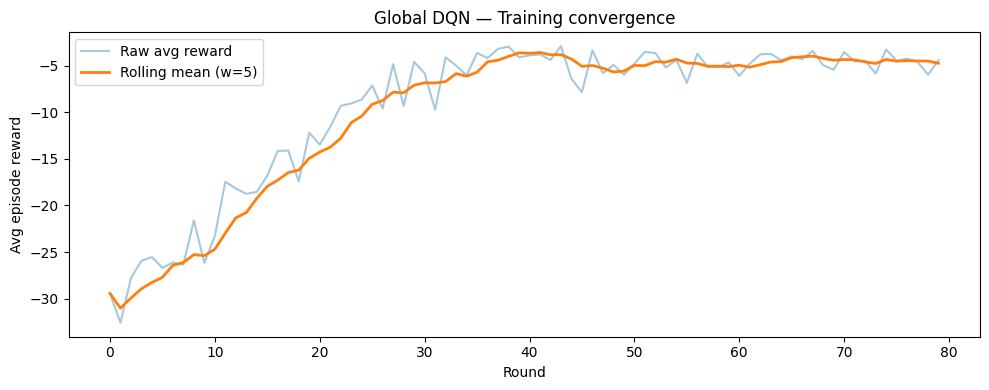

In [34]:
window = 5
trend  = pd.Series(training_rewards).rolling(window=window, min_periods=1).mean().tolist()

plt.figure(figsize=(10, 4))
plt.plot(training_rewards, alpha=0.4, label='Raw avg reward')
plt.plot(trend, linewidth=2, label=f'Rolling mean (w={window})')
plt.xlabel('Round'); plt.ylabel('Avg episode reward')
plt.title('Global DQN — Training convergence')
plt.legend(); plt.tight_layout(); plt.show()

## Cell 9 — Evaluate on 10 datasets (5 seen + 5 unseen)

In [35]:
def evaluate_user(agent, uid, verbose=False):
    """Run one full greedy episode on the test split of `uid`. Returns total cost (AUD)."""
    env = make_env(uid, split='test')
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})

    saved_eps   = agent.epsilon
    agent.epsilon = 0.0

    last_info = {}
    steps = len(test_dfs[uid]) - 1

    for _ in range(steps):
        action = agent.choose_action(obs)
        obs, _, terminated, truncated, info = env.step(action)
        last_info = info
        if terminated or truncated:
            break

    agent.epsilon = saved_eps
    cost = float(last_info.get('cumulative_payment', 0.0))
    if verbose:
        print(f'  User {uid:3d}: {cost:.2f} AUD')
    return cost


def no_battery_baseline(uid):
    """Run the test split with bat_kapaciteta=0 and always action 4 (idle).
    Uses the identical calculate_interval_price cost logic as evaluate_user."""
    env = HouseholdEnvironment(
        dataset          = test_dfs[uid],
        dataset_norm     = test_norm_dfs[uid],
        observation_mode = 'sliding_window',
        reset_mode       = 'deterministic',
        episode_length   = len(test_dfs[uid]) - 1,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = 0,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})
    last_info = {}
    for _ in range(len(test_dfs[uid]) - 1):
        obs, _, terminated, truncated, last_info = env.step(4)  # 4 = idle, no battery
        if terminated or truncated:
            break
    return float(last_info.get('cumulative_payment', 0.0))


print('Evaluating global DQN on 10 datasets...')
results = []

for uid in eval_seen:
    cost     = evaluate_user(agent, uid, verbose=True)
    baseline = no_battery_baseline(uid)
    results.append({'uid': uid, 'group': 'seen', 'cost_aud': cost, 'baseline_aud': baseline})

for uid in eval_unseen:
    cost     = evaluate_user(agent, uid, verbose=True)
    baseline = no_battery_baseline(uid)
    results.append({'uid': uid, 'group': 'unseen', 'cost_aud': cost, 'baseline_aud': baseline})

df_results = pd.DataFrame(results)
df_results['improvement_%'] = (
    (df_results['baseline_aud'] - df_results['cost_aud']) / df_results['baseline_aud'].abs() * 100
).round(1)

print('\n── Results ────────────────────────────────────────────')
print(df_results.to_string(index=False))

Evaluating global DQN on 10 datasets...
  User 242: 1589.91 AUD
  User 215: 1094.34 AUD
  User  43: 950.21 AUD
  User  93: 1080.50 AUD
  User  19: 879.25 AUD
  User 262: 1364.85 AUD
  User 294: 1711.38 AUD
  User  62: 1816.89 AUD
  User 254: 1502.82 AUD
  User 167: 1044.68 AUD

── Results ────────────────────────────────────────────
 uid  group    cost_aud  baseline_aud  improvement_%
 242   seen 1589.912903   1707.309669            6.9
 215   seen 1094.335729   1177.977920            7.1
  43   seen  950.208666   1018.568781            6.7
  93   seen 1080.495499   1167.471368            7.4
  19   seen  879.253001    941.751923            6.6
 262 unseen 1364.849715   1471.988853            7.3
 294 unseen 1711.384619   1837.500256            6.9
  62 unseen 1816.887587   1970.503459            7.8
 254 unseen 1502.818804   1609.158951            6.6
 167 unseen 1044.682109   1146.803047            8.9


In [36]:
def run_milp_for_user(uid, verbose=False):
    """
    Continuous MILP benchmark on the test split of `uid`.
    Same formulation as the single-user notebook (run_milp_benchmark, continuous mode).
    Returns total cost (AUD) — the theoretical optimum with perfect foresight.
    Note: uses N_STEPS as the local loop variable to avoid shadowing torch alias T.
    """
    env = HouseholdEnvironment(
        dataset          = test_dfs[uid],
        dataset_norm     = test_norm_dfs[uid],
        observation_mode = 'sliding_window',
        reset_mode       = 'deterministic',
        episode_length   = len(test_dfs[uid]) - 1,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = BatKapaciteta,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )

    N_STEPS = env.episode_length
    start_idx = 0
    gen   = env.arr_Gen[start_idx : start_idx + N_STEPS]
    con   = env.arr_Con[start_idx : start_idx + N_STEPS]
    smp   = env.arr_SMP[start_idx : start_idx + N_STEPS]
    dates = env.dataset.index[start_idx : start_idx + N_STEPS]
    INTERVAL_MINS = int(round(1440.0 / env.korakov_na_dan))

    # Pre-calculate per-step tariff rates (same as single-user notebook)
    import_rates   = []
    export_rates   = []
    constant_costs = []
    for t in range(N_STEPS):
        imp = calculate_interval_price(smp[t], 1.0,  dates[t], INTERVAL_MINS)
        import_rates.append(imp['variable_price_aud'])
        constant_costs.append(imp['constant_price_aud'])
        exp = calculate_interval_price(smp[t], -1.0, dates[t], INTERVAL_MINS)
        export_rates.append(-exp['variable_price_aud'])

    # Build MILP (continuous relaxation)
    prob  = pulp.LpProblem(f'Microgrid_User{uid}', pulp.LpMinimize)
    P_buy = [pulp.LpVariable(f'P_buy_{t}', lowBound=0) for t in range(N_STEPS)]
    P_sel = [pulp.LpVariable(f'P_sel_{t}', lowBound=0) for t in range(N_STEPS)]
    E     = [pulp.LpVariable(f'E_{t}', lowBound=0, upBound=env.bat_kapaciteta) for t in range(N_STEPS + 1)]
    P_ch  = [pulp.LpVariable(f'P_ch_{t}',  lowBound=0, upBound=env.bat_max_polnjenje)  for t in range(N_STEPS)]
    P_dis = [pulp.LpVariable(f'P_dis_{t}', lowBound=0, upBound=env.bat_max_praznjenje) for t in range(N_STEPS)]

    prob += (E[0] == max(0.0, env.bat_kapaciteta / 2.0))
    for t in range(N_STEPS):
        prob += (gen[t] + P_buy[t] + P_dis[t] == con[t] + P_sel[t] + P_ch[t])
        prob += (E[t + 1] == E[t] + P_ch[t] * env.bat_ucinkovitost - P_dis[t] / env.bat_ucinkovitost)

    prob += pulp.lpSum(
        P_buy[t] * import_rates[t] - P_sel[t] * export_rates[t] + constant_costs[t]
        for t in range(N_STEPS)
    )

    pulp.PULP_CBC_CMD(msg=False).solve(prob)

    if pulp.LpStatus[prob.status] != 'Optimal':
        print(f'  [WARN] User {uid}: solver status = {pulp.LpStatus[prob.status]}')

    total_cost = sum(
        (P_buy[t].varValue or 0.0) * import_rates[t]
        - (P_sel[t].varValue or 0.0) * export_rates[t]
        + constant_costs[t]
        for t in range(N_STEPS)
    )
    if verbose:
        print(f'  User {uid:3d} MILP: {total_cost:.2f} AUD')
    return total_cost


# Run MILP for all 10 eval users (this takes a few minutes per user)
print('Running MILP benchmark for 10 eval datasets (continuous relaxation)...')
milp_costs = {}
for uid in eval_ids:
    milp_costs[uid] = run_milp_for_user(uid, verbose=True)

# Merge MILP costs into df_results
df_results['milp_aud'] = df_results['uid'].map(milp_costs)

# Compute all comparison metrics
df_results['imp_dqn_%']         = ((df_results['baseline_aud'] - df_results['cost_aud'])  / df_results['baseline_aud'] * 100).round(1)
df_results['imp_milp_%']        = ((df_results['baseline_aud'] - df_results['milp_aud'])  / df_results['baseline_aud'] * 100).round(1)
df_results['gap_dqn_vs_milp_%'] = ((df_results['cost_aud']     - df_results['milp_aud'])  / df_results['milp_aud']     * 100).round(1)
df_results['fraction_theor_%']  = ((df_results['baseline_aud'] - df_results['cost_aud'])  / (df_results['baseline_aud'] - df_results['milp_aud']) * 100).round(1)

print('\nDone.')

Running MILP benchmark for 10 eval datasets (continuous relaxation)...
  User 242 MILP: 1174.74 AUD
  User 215 MILP: 899.59 AUD
  User  43 MILP: 818.07 AUD
  User  93 MILP: 853.66 AUD
  User  19 MILP: 778.15 AUD
  User 262 MILP: 1067.98 AUD
  User 294 MILP: 1242.91 AUD
  User  62 MILP: 1267.04 AUD
  User 254 MILP: 1127.11 AUD
  User 167 MILP: 796.07 AUD

Done.


# Cell 10: Resoults and visualization

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
PER-USER RESULTS
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
 User  Group  No-battery (AUD)   DQN (AUD)  MILP optimum (AUD)  DQN impr. vs base (%)  MILP impr. vs base (%)  DQN gap vs MILP (%)  DQN fraction of theor. gain (%)
  242   seen       1707.309669 1589.912903         1174.744435                    6.9                    31.2                 35.3                             22.0
  215   seen       1177.977920 1094.335729          899.594100                    7.1                    23.6                 21.6                             30.0
   43   seen       1018.568781  950.208666          818.073034                    6.7                    19.7                 16.2                             34.1
   93   seen       1167.471368 1080.495499          853.656784                    7.4

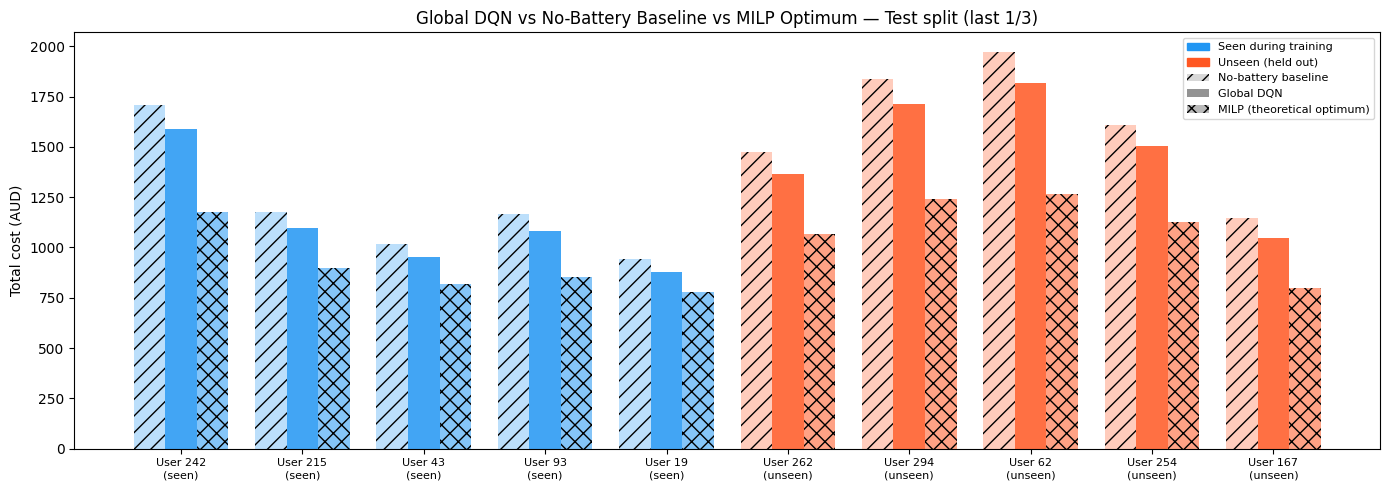

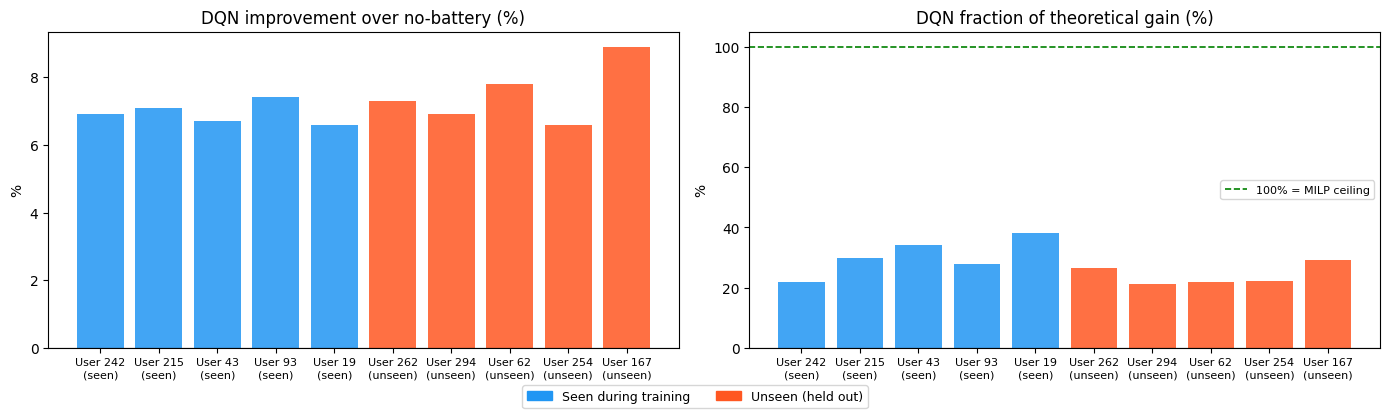

Plots saved: global_dqn_costs.png, global_dqn_improvement.png


In [37]:
# ── Per-user results table ───────────────────────────────────
display_cols = {
    'uid':               'User',
    'group':             'Group',
    'baseline_aud':      'No-battery (AUD)',
    'cost_aud':          'DQN (AUD)',
    'milp_aud':          'MILP optimum (AUD)',
    'imp_dqn_%':         'DQN impr. vs base (%)',
    'imp_milp_%':        'MILP impr. vs base (%)',
    'gap_dqn_vs_milp_%': 'DQN gap vs MILP (%)',
    'fraction_theor_%':  'DQN fraction of theor. gain (%)',
}
df_display = df_results[list(display_cols.keys())].rename(columns=display_cols)
print('═' * 120)
print('PER-USER RESULTS')
print('═' * 120)
print(df_display.to_string(index=False))

# ── Group averages ───────────────────────────────────────────
print('\n' + '═' * 80)
print('GROUP AVERAGES')
print('═' * 80)
group_avg = df_results.groupby('group').agg(
    N               = ('uid',               'count'),
    Baseline_AUD    = ('baseline_aud',      'mean'),
    DQN_AUD         = ('cost_aud',          'mean'),
    MILP_AUD        = ('milp_aud',          'mean'),
    DQN_impr_pct    = ('imp_dqn_%',         'mean'),
    MILP_impr_pct   = ('imp_milp_%',        'mean'),
    Gap_MILP_pct    = ('gap_dqn_vs_milp_%', 'mean'),
    Frac_theor_pct  = ('fraction_theor_%',  'mean'),
).round(2)
group_avg.columns = [
    'N', 'Baseline (AUD)', 'DQN (AUD)', 'MILP (AUD)',
    'DQN impr.%', 'MILP impr.%', 'DQN gap vs MILP%', 'Frac. of theor. gain%'
]
print(group_avg.to_string())

# ── Bar chart: absolute costs ────────────────────────────────
x          = np.arange(len(df_results))
width      = 0.26
colors     = {'seen': '#2196F3', 'unseen': '#FF5722'}
bar_colors = [colors[g] for g in df_results['group']]
xlabels    = [f'User {r.uid}\n({r.group})' for r in df_results.itertuples()]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, df_results['baseline_aud'], width, color=bar_colors, alpha=0.30, hatch='//')
ax.bar(x,         df_results['cost_aud'],     width, color=bar_colors, alpha=0.85)
ax.bar(x + width, df_results['milp_aud'],     width, color=bar_colors, alpha=0.55, hatch='xx')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel('Total cost (AUD)')
ax.set_title('Global DQN vs No-Battery Baseline vs MILP Optimum — Test split (last 1/3)')
ax.legend(handles=[
    mpatches.Patch(color=colors['seen'],   label='Seen during training'),
    mpatches.Patch(color=colors['unseen'], label='Unseen (held out)'),
    mpatches.Patch(facecolor='grey', alpha=0.30, hatch='//', label='No-battery baseline'),
    mpatches.Patch(facecolor='grey', alpha=0.85,             label='Global DQN'),
    mpatches.Patch(facecolor='grey', alpha=0.55, hatch='xx', label='MILP (theoretical optimum)'),
], loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('global_dqn_costs.png', dpi=150)
plt.show()

# ── Two-panel improvement chart ──────────────────────────────
fig2, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 4))

ax_left.bar(x, df_results['imp_dqn_%'], color=bar_colors, alpha=0.85)
ax_left.axhline(0, color='black', linewidth=0.8)
ax_left.set_xticks(x); ax_left.set_xticklabels(xlabels, fontsize=8)
ax_left.set_ylabel('%'); ax_left.set_title('DQN improvement over no-battery (%)')

ax_right.bar(x, df_results['fraction_theor_%'], color=bar_colors, alpha=0.85)
ax_right.axhline(0,   color='black', linewidth=0.8)
ax_right.axhline(100, color='green', linewidth=1.2, linestyle='--', label='100% = MILP ceiling')
ax_right.set_xticks(x); ax_right.set_xticklabels(xlabels, fontsize=8)
ax_right.set_ylabel('%'); ax_right.set_title('DQN fraction of theoretical gain (%)')
ax_right.legend(fontsize=8)

fig2.legend(handles=[
    mpatches.Patch(color=colors['seen'],   label='Seen during training'),
    mpatches.Patch(color=colors['unseen'], label='Unseen (held out)'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.tight_layout()
plt.savefig('global_dqn_improvement.png', dpi=150)
plt.show()

print('Plots saved: global_dqn_costs.png, global_dqn_improvement.png')